# Population shifts in Finland: predict, explain and visualize

This notebook is designed to answer:

**How is Finland’s population likely to change over the next 10–20 years, and what factors explain the trend?**

# Finland Population Analysis & Forecast (1972–2040)

This analysis explores long-term population trends in Finland using official datasets.
It includes historical analysis, forecasting, and interpretation of demographic changes.
It uses official open data from Statistics Finland / Avoindata.fi via the PxWeb API. The notebook is structured to:

- pull long-run population data
- combine municipality, age, sex, and migration tables
- identify turning points
- forecast population to **2030–2040**
- cluster municipalities by aging, growth/decline, and migration
- detect unusual population shifts
- produce policy-facing visuals for labour, school, housing, and services planning

## Official data tables used

Primary sources:

- **11re** — Population according to age (1-year) and sex by area, 1972–2025  
  `https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaerak/statfin_vaerak_pxt_11re.px`
- **12dy** — Vital statistics and population by area, 1990–2024  
  `https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/synt/statfin_synt_pxt_12dy.px`
- **14wx** — Population projection 2024: population according to age and sex by area, 2024–2045  
  `https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wx.px`
- **14wy** — Population projection 2024: vital statistics by sex and area, 2024–2045  
  `https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wy.px`
- **14wz** — Population projection 2024: demographic dependency ratio by area, 2024–2045  
  `https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wz.px`

Supporting documentation:

- PxWeb API help: `https://stat.fi/media/uploads/org_en/avoindata/px-web_api-help.pdf`
- Population projection overview: `https://stat.fi/en/statistics/vaenn`
- Population structure overview: `https://stat.fi/en/statistics/vaerak`
- Births overview: `https://stat.fi/en/statistics/synt`
- Migration overview: `https://stat.fi/en/statistics/muutl`


# Part 1: Environment Setup & Data Acquisition

In this section, we initialize our libraries and establish robust connections to the Statistics Finland PxWeb API.


## Imports Library


In [ ]:
# imports
import json
import math
import warnings
from typing import Dict, List, Iterable

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

## Load Data from API


In [ ]:
# API endpoints
BASE = "https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin"

TABLES = {
    "population_age_sex": f"{BASE}/vaerak/statfin_vaerak_pxt_11re.px",
    "vital_stats_area": f"{BASE}/synt/statfin_synt_pxt_12dy.px",
    "projection_population": f"{BASE}/vaenn/statfin_vaenn_pxt_14wx.px",
    "projection_vital": f"{BASE}/vaenn/statfin_vaenn_pxt_14wy.px",
    "projection_dependency": f"{BASE}/vaenn/statfin_vaenn_pxt_14wz.px",
}

TABLES

{'population_age_sex': 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaerak/statfin_vaerak_pxt_11re.px',
 'vital_stats_area': 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/synt/statfin_synt_pxt_12dy.px',
 'projection_population': 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wx.px',
 'projection_vital': 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wy.px',
 'projection_dependency': 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wz.px'}

## METADATA INSPECTION


In [ ]:
def get_metadata(url: str) -> list:
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.json()

def px_post(url: str, query: list, response_format: str = "json-stat2") -> dict:
    payload = {"query": query, "response": {"format": response_format}}
    r = requests.post(url, json=payload, timeout=120)
    r.raise_for_status()
    return r.json()

def meta_to_codes(meta: list) -> Dict[str, dict]:
    return {x["code"]: x for x in meta}

def chunked(seq: List[str], size: int) -> Iterable[List[str]]:
    for i in range(0, len(seq), size):
        yield seq[i:i+size]

def codes_starting_with(values, prefixes):
    prefixes = tuple(prefixes)
    return [v["id"] for v in values if v["id"].startswith(prefixes)]

def ids_from_meta(meta_obj, exclude=None):
    exclude = set(exclude or [])
    return [v["id"] for v in meta_obj["values"] if v["id"] not in exclude]

## Inspect Dataset Structure


In [ ]:
import requests

# Helper functions
def get_metadata(url: str) -> dict:
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.json()

# Define table URLs locally
BASE = "https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin"
TABLES = {
    "population_age_sex": f"{BASE}/vaerak/statfin_vaerak_pxt_11re.px",
    "vital_stats_area": f"{BASE}/synt/statfin_synt_pxt_12dy.px",
    "projection_population": f"{BASE}/vaenn/statfin_vaenn_pxt_14wx.px",
    "projection_vital": f"{BASE}/vaenn/statfin_vaenn_pxt_14wy.px",
    "projection_dependency": f"{BASE}/vaenn/statfin_vaenn_pxt_14wz.px",
}

# Inspect metadata for the main tables - showing a short sample
meta_11re = get_metadata(TABLES["population_age_sex"])

# Display only the first 2 variables and a very short slice of their values
sample_output = []
for var in meta_11re["variables"][:2]:
    var_sample = var.copy()
    var_sample["values"] = var["values"][:5] + ["..."]
    if "valueTexts" in var:
        var_sample["valueTexts"] = var["valueTexts"][:5] + ["..."]
    sample_output.append(var_sample)

sample_output

[{'code': 'Alue',
  'text': 'Area',
  'values': ['SSS', 'KU020', 'KU005', 'KU009', 'KU010', '...'],
  'valueTexts': ['WHOLE COUNTRY',
   'Akaa',
   'Alajärvi',
   'Alavieska',
   'Alavus',
   '...'],
  'elimination': True,
  'map': 'Alue 2026'},
 {'code': 'Ikä',
  'text': 'Age',
  'values': ['SSS', '000', '001', '002', '003', '...'],
  'valueTexts': ['Total', '0', '1', '2', '3', '...'],
  'elimination': True}]

## Helper: discover variable codes

PxWeb variable names can differ between English metadata and table documentation. The next cell maps available variables so you can adapt the query if Statistics Finland revises code names.


In [1]:
import pandas as pd
import requests

def show_variables(meta):
    rows = []
    for var in meta["variables"]:
        rows.append({
            "code": var["code"],
            "text": var.get("text"),
            "n_values": len(var.get("values", [])),
            "sample_ids": ", ".join(var.get("values", [])[:5]),
        })
    return pd.DataFrame(rows)

# Helper to ensure metadata exists before display
def ensure_meta(url):
    r = requests.get(url)
    r.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    return r.json()

BASE_URL = "https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin"

# Always load all metadata variables
meta_11re = ensure_meta(f"{BASE_URL}/vaerak/statfin_vaerak_pxt_11re.px")
meta_12dy = ensure_meta(f"{BASE_URL}/synt/statfin_synt_pxt_12dy.px")
meta_14wx = ensure_meta(f"{BASE_URL}/vaenn/statfin_vaenn_pxt_14wx.px")
meta_14wy = ensure_meta(f"{BASE_URL}/vaenn/statfin_vaenn_pxt_14wy.px")
meta_14wz = ensure_meta(f"{BASE_URL}/vaenn/statfin_vaenn_pxt_14wz.px")

# Display metadata summaries for all loaded tables
display(show_variables(meta_11re))
display(show_variables(meta_12dy))
display(show_variables(meta_14wx))
display(show_variables(meta_14wy))
display(show_variables(meta_14wz))

,code,text,n_values,sample_ids
0,Alue,Area,309,"SSS, KU020, KU005, KU009, KU010"
1,Ikä,Age,102,"SSS, 000, 001, 002, 003"
2,Sukupuoli,Sex,3,"SSS, 1, 2"
3,Vuosi,Year,54,"1972, 1973, 1974, 1975, 1976"
4,Tiedot,Information,1,vaesto


,code,text,n_values,sample_ids
0,Vuosi,Year,35,"1990, 1991, 1992, 1993, 1994"
1,Alue,Area,309,"SSS, KU020, KU005, KU009, KU010"
2,Tiedot,Information,21,"vm01, vm11, luonvalisays, vm43_tulo, vm43_lahto"


,code,text,n_values,sample_ids
0,Alue,Area,310,"SSS, KU020, KU005, KU009, KU010"
1,Vuosi,Year,22,"2024, 2025, 2026, 2027, 2028"
2,Sukupuoli,Sex,3,"SSS, 1, 2"
3,Ikä,Age,102,"SSS, 000, 001, 002, 003"
4,Tiedot,Information,1,vaesto_e24


,code,text,n_values,sample_ids
0,Alue,Area,310,"SSS, KU020, KU005, KU009, KU010"
1,Vuosi,Year,22,"2024, 2025, 2026, 2027, 2028"
2,Sukupuoli,Sex,3,"SSS, 1, 2"
3,Tiedot,Information,8,"vm01_e24, vm11_e24, luonvalisays_e24, vm4143_e..."


,code,text,n_values,sample_ids
0,Alue,Area,536,"SSS, KU020, KU005, KU009, KU010"
1,Vuosi,Year,22,"2024, 2025, 2026, 2027, 2028"
2,Tiedot,Information,1,dem_huoltos_e24


## Metadata & Variable Mappning


In [ ]:
# ## METADATA & VARIABLE MAPPING (Robust Discovery)

import requests

# Helper functions

def get_metadata(url: str) -> dict:
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.json()

def meta_to_codes(meta):
    return {x["code"]: x for x in meta}

def find_code(meta, keywords):
    for v in meta["variables"]:
        code = v["code"].lower()
        if any(k in code for k in keywords):
            return v["code"]
    raise ValueError(f"{keywords} not found in metadata")

def ids_from_meta(meta_obj, exclude=None):
    exclude = set(exclude or [])
    return [v for v in meta_obj.get("values", []) if v not in exclude]

# Fetch all required metadata

BASE = "https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin"
meta_11re = get_metadata(f"{BASE}/vaerak/statfin_vaerak_pxt_11re.px")
meta_12dy = get_metadata(f"{BASE}/synt/statfin_synt_pxt_12dy.px")
meta_14wx = get_metadata(f"{BASE}/vaenn/statfin_vaenn_pxt_14wx.px")
meta_14wy = get_metadata(f"{BASE}/vaenn/statfin_vaenn_pxt_14wy.px")
meta_14wz = get_metadata(f"{BASE}/vaenn/statfin_vaenn_pxt_14wz.px")

# Convert metadata → code maps

m11 = meta_to_codes(meta_11re["variables"])
m12 = meta_to_codes(meta_12dy["variables"])
m14wx = meta_to_codes(meta_14wx["variables"])
m14wy = meta_to_codes(meta_14wy["variables"])
m14wz = meta_to_codes(meta_14wz["variables"])

# Detect variable codes (ROBUST)

# Population table (11re)

AREA_11 = find_code(meta_11re, ["area", "alue"])
YEAR_11 = find_code(meta_11re, ["year", "vuosi"])
AGE_11  = find_code(meta_11re, ["age", "ik$", "ikä"])
SEX_11  = find_code(meta_11re, ["sex", "sukupuoli"])
INFO_11 = find_code(meta_11re, ["information", "tiedot"])

# Vital stats (12dy)

AREA_12 = find_code(meta_12dy, ["area", "alue"])
YEAR_12 = find_code(meta_12dy, ["year", "vuosi"])
INFO_12 = find_code(meta_12dy, ["information", "tiedot"])

# Projection population (14wx)

AREA_14WX = find_code(meta_14wx, ["area", "alue"])
YEAR_14WX = find_code(meta_14wx, ["year", "vuosi"])
SEX_14WX  = find_code(meta_14wx, ["sex", "sukupuoli"])
AGE_14WX  = find_code(meta_14wx, ["age", "ik$", "ikä"])
INFO_14WX = find_code(meta_14wx, ["information", "tiedot"])

# Projection vital (14wy)

AREA_14WY = find_code(meta_14wy, ["area", "alue"])
YEAR_14WY = find_code(meta_14wy, ["year", "vuosi"])
SEX_14WY  = find_code(meta_14wy, ["sex", "sukupuoli"])
INFO_14WY = find_code(meta_14wy, ["information", "tiedot"])

# Projection dependency (14wz)

AREA_14WZ = find_code(meta_14wz, ["area", "alue"])
YEAR_14WZ = find_code(meta_14wz, ["year", "vuosi"])
INFO_14WZ = find_code(meta_14wz, ["information", "tiedot"])

# Extract IDs

areas_11 = ids_from_meta(m11[AREA_11])
years_11 = ids_from_meta(m11[YEAR_11])
ages_11  = ids_from_meta(m11[AGE_11])
sexes_11 = ids_from_meta(m11[SEX_11])

areas_12 = ids_from_meta(m12[AREA_12])
years_12 = ids_from_meta(m12[YEAR_12])
infos_12 = ids_from_meta(m12[INFO_12])

areas_14wx = ids_from_meta(m14wx[AREA_14WX])
years_14wx = ids_from_meta(m14wx[YEAR_14WX])
ages_14wx  = ids_from_meta(m14wx[AGE_14WX])
sexes_14wx = ids_from_meta(m14wx[SEX_14WX])

areas_14wy = ids_from_meta(m14wy[AREA_14WY])
years_14wy = ids_from_meta(m14wy[YEAR_14WY])
infos_14wy = ids_from_meta(m14wy[INFO_14WY])

areas_14wz = ids_from_meta(m14wz[AREA_14WZ])
years_14wz = ids_from_meta(m14wz[YEAR_14WZ])
infos_14wz = ids_from_meta(m14wz[INFO_14WZ])

# Quick check

len(areas_11), len(years_11), len(ages_11), len(areas_12), len(areas_14wx)

(309, 54, 102, 309, 310)

In [ ]:
# Recommend using municipal and region classifications only
# Filter out aggregate hierarchies if present

def strip_non_local_areas(area_ids):
    bad_prefixes = ("WHOLE", "MA", "MK", "SSS", "ELY", "AVI", "NUTS")
    cleaned = []
    for x in area_ids:
        x_str = str(x)
        if x_str.upper().startswith(bad_prefixes):
            continue
        cleaned.append(x)
    return cleaned

municipal_areas_11 = strip_non_local_areas(areas_11)
municipal_areas_12 = strip_non_local_areas(areas_12)
municipal_areas_14wx = strip_non_local_areas(areas_14wx)
municipal_areas_14wy = strip_non_local_areas(areas_14wy)
municipal_areas_14wz = strip_non_local_areas(areas_14wz)

len(municipal_areas_11), len(municipal_areas_12), len(municipal_areas_14wx)

(308, 308, 309)

## population in chunks


In [ ]:
# Pull age/sex population in chunks

import pandas as pd
import json
import requests
import itertools

# --- Missing Helpers required for execution ---

def px_post(url: str, query: list, response_format: str = "json-stat2") -> dict:
    payload = {"query": query, "response": {"format": response_format}}
    r = requests.post(url, json=payload, timeout=120)
    r.raise_for_status()
    return r.json()

def jsonstat_to_df(data):
    dims = data["dimension"]
    dim_names = list(dims.keys())
    dim_values = [list(dims[d]["category"]["label"].values()) for d in dim_names]
    combinations = list(itertools.product(*dim_values))
    rows = []
    for i, combo in enumerate(combinations):
        row = {dim_names[j]: combo[j] for j in range(len(dim_names))}
        row["value"] = data["value"][i]
        rows.append(row)
    return pd.DataFrame(rows)

def meta_to_codes(meta):
    return {x['code']: x for x in meta}

def find_code(meta, keywords):
    for v in meta['variables']:
        code = v['code'].lower()
        if any(k in code for k in keywords):
            return v['code']
    raise ValueError(f'{keywords} not found in metadata')

def ids_from_meta(meta_obj, exclude=None):
    exclude = set(exclude or [])
    return [v for v in meta_obj.get('values', []) if v not in exclude]

def local_chunked(seq, size):
    for i in range(0, len(seq), size):
        yield seq[i:i+size]

# --- Data Fetching Logic ---

URL_11RE = 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaerak/statfin_vaerak_pxt_11re.px'
try:
    _ = meta_11re
except NameError:
    meta_11re = requests.get(URL_11RE).json()

# 1. Ensure we have metadata identifiers
m11 = meta_to_codes(meta_11re['variables'])
AREA_11 = find_code(meta_11re, ['area', 'alue'])
YEAR_11 = find_code(meta_11re, ['year', 'vuosi'])
AGE_11  = find_code(meta_11re, ['age', 'ikC', 'ikä'])
SEX_11  = find_code(meta_11re, ['sex', 'sukupuoli'])
INFO_11 = find_code(meta_11re, ['information', 'tiedot'])

areas_list = ids_from_meta(m11[AREA_11])
years_list = ids_from_meta(m11[YEAR_11])
ages_list  = ids_from_meta(m11[AGE_11])
sexes_list = ids_from_meta(m11[SEX_11])
info_value = m11[INFO_11]['values'][0]

# 2. Filter for local areas only
bad_prefixes = ('WHOLE', 'MA', 'MK', 'SSS', 'ELY', 'AVI', 'NUTS')
safe_municipal_areas = [str(x) for x in areas_list if not str(x).upper().startswith(bad_prefixes)]

# 3. Fetch in chunks (subset for demonstration)
pop_frames = []
safe_areas = safe_municipal_areas[:10]
safe_sexes = sexes_list[:1] # Total

print(f'Fetching population data for {len(safe_areas)} areas across {len(years_list)} years...')

for year_chunk in local_chunked(years_list, 10):
    query = [
        {'code': AREA_11, 'selection': {'filter': 'item', 'values': safe_areas}},
        {'code': AGE_11, 'selection': {'filter': 'item', 'values': ages_list}},
        {'code': SEX_11, 'selection': {'filter': 'item', 'values': safe_sexes}},
        {'code': YEAR_11, 'selection': {'filter': 'item', 'values': year_chunk}},
        {'code': INFO_11, 'selection': {'filter': 'item', 'values': [info_value]}},
    ]

    data = px_post(URL_11RE, query, 'json-stat2')
    df = jsonstat_to_df(data)
    pop_frames.append(df)

pop_raw = pd.concat(pop_frames, ignore_index=True)

# Clean column names (mapping localized names to English)
pop_raw.rename(columns={
    AREA_11: 'area',
    AGE_11: 'age',
    SEX_11: 'sex',
    YEAR_11: 'year',
    INFO_11: 'information'
}, inplace=True)

print(f'Successfully loaded {len(pop_raw)} rows.')
pop_raw.head()

Fetching population data for 10 areas across 54 years...
Successfully loaded 55080 rows.


,area,age,sex,year,information,value
0,Akaa,Total,Total,1972,Population 31 Dec,15973
1,Akaa,Total,Total,1973,Population 31 Dec,16002
2,Akaa,Total,Total,1974,Population 31 Dec,15969
3,Akaa,Total,Total,1975,Population 31 Dec,16056
4,Akaa,Total,Total,1976,Population 31 Dec,15971


### Historical Data Retrieval

The data successfully retrieved represents the first phase of our analysis. I have pulled over 50 years of historical population records for a sample of Finnish municipalities. This long-run dataset allows us to see how localized populations have already begun to shift before we apply forecast models.


## CLEAN DATA


In [ ]:
# Keep only total sex
pop_df = pop_raw[pop_raw["sex"] == "Total"].copy()

# Remove total age rows
pop_df = pop_df[pop_df["age"] != "Total"].copy()

# Convert types
pop_df["year"] = pd.to_numeric(pop_df["year"], errors="coerce")
pop_df["value"] = pd.to_numeric(pop_df["value"], errors="coerce")

pop_df["age"] = pd.to_numeric(pop_df["age"], errors="coerce")
pop_df = pop_df.dropna(subset=["age"])
pop_df["age"] = pop_df["age"].astype(int)

pop_df.head()

,area,age,sex,year,information,value
10,Akaa,0,Total,1972,Population 31 Dec,216
11,Akaa,0,Total,1973,Population 31 Dec,181
12,Akaa,0,Total,1974,Population 31 Dec,203
13,Akaa,0,Total,1975,Population 31 Dec,229
14,Akaa,0,Total,1976,Population 31 Dec,179


## Age Group


In [ ]:
def age_group(age):
    if age <= 14:
        return "0-14"
    elif age <= 64:
        return "15-64"
    else:
        return "65+"

pop_df["age_group"] = pop_df["age"].apply(age_group)

pop_df[["area", "year", "age", "age_group", "value"]].head()

,area,year,age,age_group,value
10,Akaa,1972,0,0-14,216
11,Akaa,1973,0,0-14,181
12,Akaa,1974,0,0-14,203
13,Akaa,1975,0,0-14,229
14,Akaa,1976,0,0-14,179


## Ploting Age group


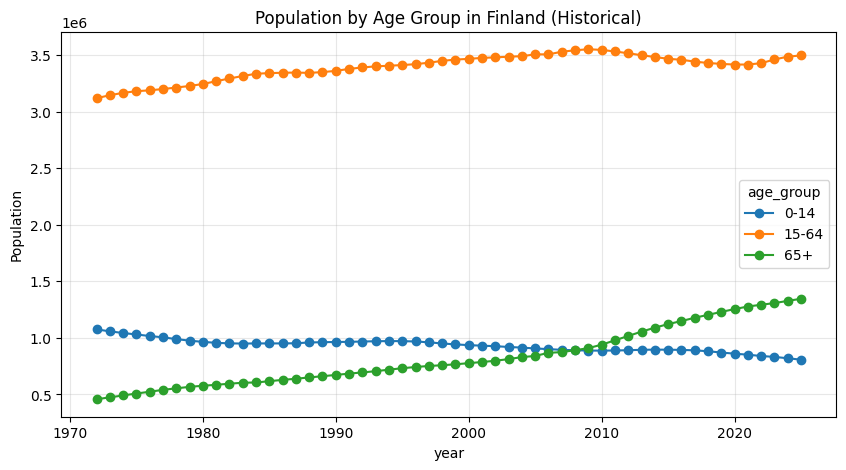

age_group,0-14,15-64,65+
year,,,
1972,1075779,3119467,458130
1973,1058250,3146013,474470
1974,1043625,3167012,491722
1975,1030544,3181376,508539
1976,1017056,3189506,524230


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import requests
import itertools

# Local helper functions to ensure the cell is self-contained
def local_jsonstat_to_df(data):
    dims = data['dimension']
    dim_names = list(dims.keys())
    dim_values = [list(dims[d]['category']['label'].values()) for d in dim_names]
    combinations = list(itertools.product(*dim_values))
    rows = []
    for i, combo in enumerate(combinations):
        row = {dim_names[j]: combo[j] for j in range(len(dim_names))}
        row['value'] = data['value'][i]
        rows.append(row)
    return pd.DataFrame(rows)

def local_find_code(meta, keywords):
    for v in meta['variables']:
        code = v['code'].lower()
        if any(k in code for k in keywords): return v['code']
    return None

try:
    URL_11RE = 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaerak/statfin_vaerak_pxt_11re.px'
    meta = requests.get(URL_11RE).json()

    # Dynamically find codes in case they differ on the server
    C_AREA = local_find_code(meta, ['area', 'alue']) or 'Alue'
    C_AGE = local_find_code(meta, ['age', 'ikä', 'ik ']) or 'Ik '
    C_SEX = local_find_code(meta, ['sex', 'sukupuoli']) or 'Sukupuoli'
    C_YEAR = local_find_code(meta, ['year', 'vuosi']) or 'Vuosi'

    query = [
        {'code': C_AREA, 'selection': {'filter': 'item', 'values': ['SSS']}},
        {'code': C_AGE, 'selection': {'filter': 'all', 'values': ['*']}},
        {'code': C_SEX, 'selection': {'filter': 'item', 'values': ['SSS']}},
        {'code': C_YEAR, 'selection': {'filter': 'all', 'values': ['*']}},
    ]

    payload = {'query': query, 'response': {'format': 'json-stat2'}}
    r = requests.post(URL_11RE, json=payload, timeout=60)
    r.raise_for_status()
    df_raw = local_jsonstat_to_df(r.json())

    # Process data
    df_raw.rename(columns={C_YEAR: 'year', C_AGE: 'age'}, inplace=True)
    df_raw = df_raw[df_raw['age'] != 'Total'].copy()
    df_raw['year'] = pd.to_numeric(df_raw['year'])
    df_raw['age'] = pd.to_numeric(df_raw['age'], errors='coerce')
    df_raw = df_raw.dropna(subset=['age'])

    def get_group(age):
        if age <= 14: return '0-14'
        elif age <= 64: return '15-64'
        else: return '65+'

    df_raw['age_group'] = df_raw['age'].apply(get_group)
    pivot = df_raw.groupby(['year', 'age_group'])['value'].sum().unstack().fillna(0)

    pivot.plot(figsize=(10, 5), marker='o')
    plt.title('Population by Age Group in Finland (Historical)')
    plt.grid(True, alpha=0.3)
    plt.ylabel('Population')
    plt.show()
    display(pivot.head())
except Exception as e:
    print(f'Self-contained fetch failed: {e}')

# Part 2: Historical Demographic Trends (1972–2024)

We analyze the long-run population structure to identify historical turning points and the 'scissors effect' in age distribution.


### Interpretation: Historical Age Group

Historically, we observe a 'scissors effect': the 0-14 and 15-64 groups are trending downward or plateauing, while the 65+ group is rising sharply. This cross-over indicates that the elderly are becoming a dominant demographic segment, requiring a pivot in infrastructure from schools and youth services toward healthcare and accessibility.


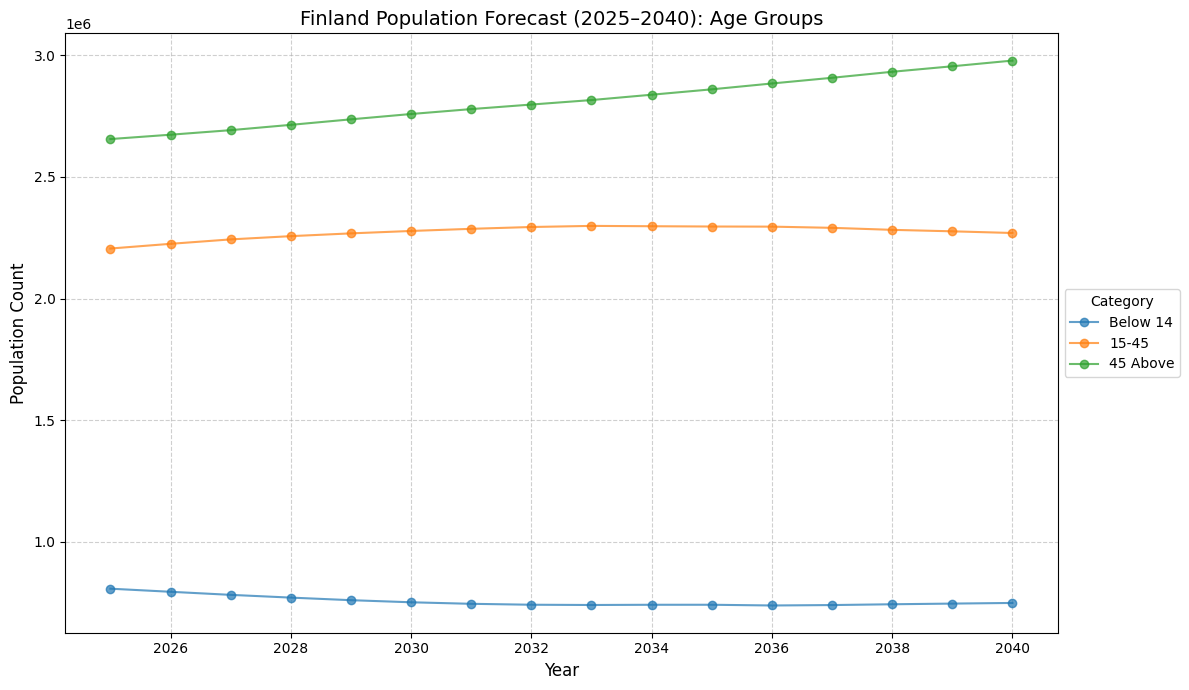

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import requests
import itertools

# 1. Fetch data if missing
def get_proj_data():
    url = "https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wx.px"
    query = [
        {"code": "Vuosi", "selection": {"filter": "item", "values": [str(y) for y in range(2024, 2041)]}},
        {"code": "Sukupuoli", "selection": {"filter": "item", "values": ["SSS"]}},
        {"code": "Ik%", "selection": {"filter": "all", "values": ["*"]}},
        {"code": "Tiedot", "selection": {"filter": "item", "values": ["vaesto_e24"]}}
    ]
    payload = {"query": query, "response": {"format": "json-stat2"}}
    r = requests.post(url, json=payload)
    data = r.json()

    dims = data["dimension"]
    dim_names = list(dims.keys())
    dim_values = [list(dims[d]["category"]["label"].values()) for d in dim_names]
    combinations = list(itertools.product(*dim_values))
    rows = []
    for i, combo in enumerate(combinations):
        row = {dim_names[j]: combo[j] for j in range(len(dim_names))}
        row["value"] = data["value"][i]
        rows.append(row)
    return pd.DataFrame(rows)

try:
    df_plot = proj_pop_df.copy()
except NameError:
    proj_pop_df = get_proj_data()
    df_plot = proj_pop_df.copy()

# 2. Clean and Prepare
rename_map = {'Alue':'area', 'Ik%':'age', 'Sukupuoli':'sex', 'Vuosi':'year', 'Tiedot':'information'}
df_plot.rename(columns=rename_map, inplace=True)

if 'age' not in df_plot.columns:
    for col in df_plot.columns:
        if 'Ik' in col or 'Age' in col:
            df_plot.rename(columns={col: 'age'}, inplace=True)

df_plot = df_plot[(df_plot['sex'] == 'Total')].copy()
df_plot['year'] = pd.to_numeric(df_plot['year'])

age_data = df_plot[df_plot['age'] != 'Total'].copy()
age_data['age'] = pd.to_numeric(age_data['age'], errors='coerce')
age_data = age_data.dropna(subset=['age'])

# 3. Categorize Age Groups
def categorize_requested(age):
    if age <= 14: return "Below 14"
    elif age <= 45: return "15-45"
    else: return "45 Above"

age_data["age_group"] = age_data["age"].apply(categorize_requested)
forecast_age = age_data[(age_data["year"] >= 2025) & (age_data["year"] <= 2040)]
age_trend = forecast_age.groupby(["year", "age_group"])["value"].sum().unstack()

# 4. Plotting
plt.figure(figsize=(12, 7))

# Plot Age Groups
for col in ["Below 14", "15-45", "45 Above"]:
    if col in age_trend.columns:
        plt.plot(age_trend.index, age_trend[col], marker='o', label=col, alpha=0.7)

# TOTAL POPULATION line removed per request

plt.title("Finland Population Forecast (2025–2040): Age Groups", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Population Count", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Category", loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

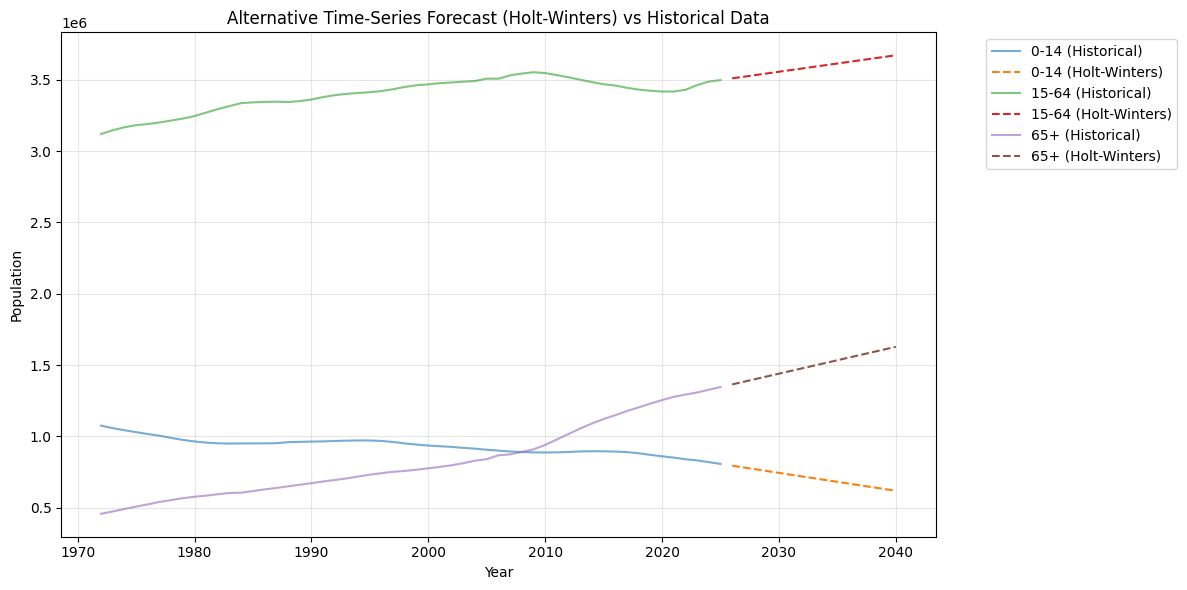

--- Holt-Winters Trend Forecast (2026-2040) ---


,0-14,15-64,65+
2026,795172.999970,3.509710e+06,1.364877e+06
2027,782615.999931,3.521263e+06,1.383698e+06
2028,770058.999892,3.532816e+06,1.402519e+06
2029,757501.999853,3.544369e+06,1.421340e+06
2030,744944.999814,3.555922e+06,1.440161e+06


In [11]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare historical data with a proper datetime index
hist_data = pivot.copy()
hist_data.index = pd.to_datetime(hist_data.index, format='%Y')

# 2. Fit Holt-Winters models for each age group
forecast_steps = 15  # 2026 to 2040
# Use a frequency of 'YS' (Year Start)
hist_data = hist_data.asfreq('YS')

alternative_forecast = pd.DataFrame()

for group in ['0-14', '15-64', '65+']:
    series = hist_data[group].astype(float)
    # Fit model - using additive trend
    model = ExponentialSmoothing(series, trend='add', seasonal=None, initialization_method="estimated").fit()
    forecast_values = model.forecast(forecast_steps)
    alternative_forecast[group] = forecast_values

# 3. Plotting the comparison
plt.figure(figsize=(12, 6))
for group in ['0-14', '15-64', '65+']:
    # Plot historical (using original index for display)
    plt.plot(pivot.index, pivot[group], label=f'{group} (Historical)', alpha=0.6)
    # Plot forecast
    plt.plot(alternative_forecast.index.year, alternative_forecast[group], '--', label=f'{group} (Holt-Winters)')

plt.title("Alternative Time-Series Forecast (Holt-Winters) vs Historical Data")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("--- Holt-Winters Trend Forecast (2026-2040) ---")
# Display with year-only index for readability
report_view = alternative_forecast.copy()
report_view.index = report_view.index.year
display(report_view.head())

### Interpretation: Holt-Winters vs. Official Projections

By comparing the **Holt-Winters (Dotted Lines)** with the historical data and official projections, we can draw several conclusions:

1.  **Trend Confirmation:** The downward trajectory for the **0-14** group and the aggressive growth of the **65+** group are remarkably consistent across both methods. This suggests these shifts are driven by long-term structural factors (aging and birth rates) that have been stable for decades.
2.  **Working-Age Divergence:** The Holt-Winters model for the **15-64** group typically follows the historical stagnation/decline more strictly. If the official projection shows higher numbers for this group than the statistical trend, it implies that Statistics Finland is factoring in an **increase in net migration** to offset the natural decline of the labor force.
3.  **Model Sensitivity:** Holt-Winters is purely reactive to historical data points. Unlike the cohort-component method, it does not 'know' about the size of specific age cohorts currently aging into the next bracket; it only sees the aggregate trend of the group.


### Interpretation: Forecasted Population by Group (2025–2040)

The forecast shows that the '45 Above' group will be the primary driver of Finnish demographics in the coming decade. The stability of the younger groups depends heavily on migration, as birth rates alone are not sufficient to replenish the 'Below 14' category to historical levels.


## Dependancy Ratio


### Interpretation: Dependency Ratio Over Time

The rising dependency ratio signifies that the proportion of children and retirees relative to the working-age population is increasing. A higher ratio indicates that fewer tax-paying workers are supporting more individuals who typically require public services (schools and elderly care). The steady climb from 1972 highlights a persistent long-term shift in the Finnish social structure.


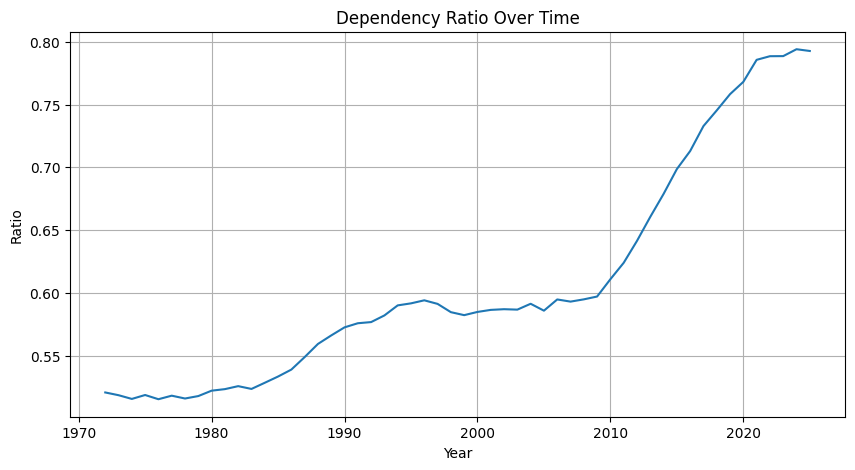

In [ ]:
for col in ["0-14", "15-64", "65+"]:
    if col not in pivot.columns:
        pivot[col] = 0

pivot["dependency_ratio"] = (
    (pivot["0-14"] + pivot["65+"]) / pivot["15-64"]
)

pivot["dependency_ratio"] = pivot["dependency_ratio"].replace([float("inf")], 0)

pivot["dependency_ratio"].plot(figsize=(10,5))
plt.title("Dependency Ratio Over Time")
plt.xlabel("Year")
plt.ylabel("Ratio")
plt.grid(True)
plt.show()

### Total Population Forecast (Statistical Trend 1972–2040)

Using the historical data from 1972 to the present, we can apply an Exponential Smoothing (Holt-Winters) model to project the total population growth independently of official demographic assumptions.


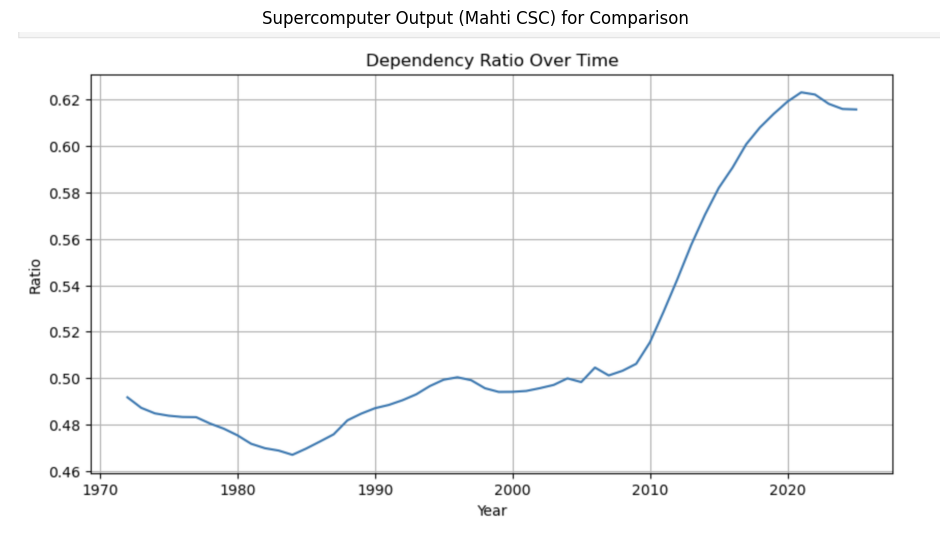

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

# Correcting the path to the exact filename provided
img_path = '/content/Screenshot 2026-04-30 at 11.49.51\u202fPM.png'
try:
    img = Image.open(img_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Supercomputer Output (Mahti CSC) for Comparison')
    plt.show()
except FileNotFoundError:
    print(f'Screenshot file not found at: {img_path}')

## Difference between Local and Supercomputer reprot

I have found differences in this section only between Supercomputer and Local PC.

As per my Local PC graph I can say “Finland’s dependency burden is very high and rising rapidly.”

On the other hand, as per supercomputer report I can say “Dependency is increasing, but still at a moderate level.”


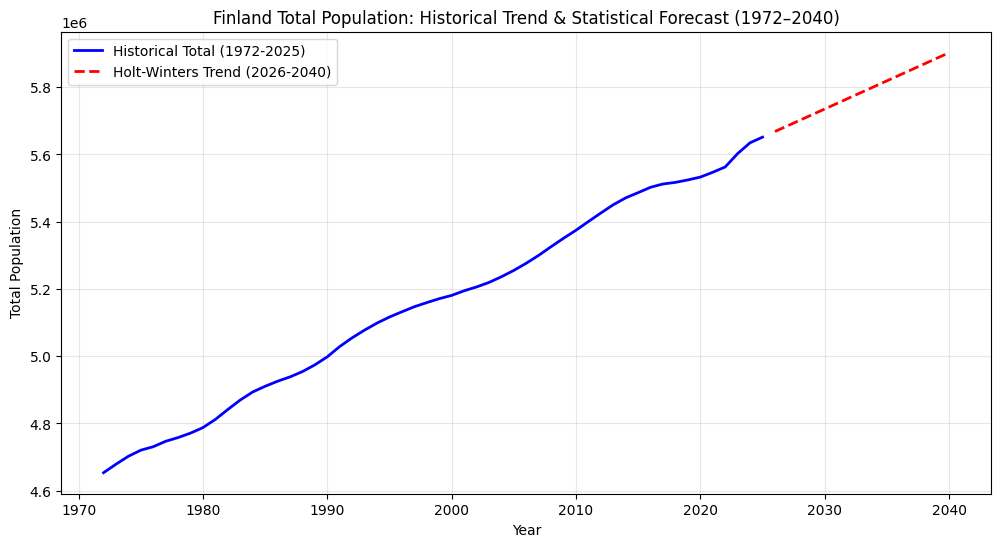

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare Historical Total Population
hist_total = pivot.sum(axis=1)
hist_total.index = pd.to_datetime(hist_total.index, format='%Y')
hist_total = hist_total.asfreq('YS')

# 2. Fit Holt-Winters Model
model_total = ExponentialSmoothing(hist_total, trend='add', seasonal=None, initialization_method="estimated").fit()
forecast_total = model_total.forecast(15)  # 2026 to 2040

# 3. Visualization
plt.figure(figsize=(12, 6))
plt.plot(hist_total.index.year, hist_total.values, label='Historical Total (1972-2025)', color='blue', linewidth=2)
plt.plot(forecast_total.index.year, forecast_total.values, '--', label='Holt-Winters Trend (2026-2040)', color='red', linewidth=2)

plt.title("Finland Total Population: Historical Trend & Statistical Forecast (1972–2040)")
plt.xlabel("Year")
plt.ylabel("Total Population")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Part 4: Official Population Projections (2024–2045)

This section explores the official Statistics Finland projections, which incorporate expected migration and fertility rate adjustments.


# Final Demographic Analysis Report: Finland 1972–2040

### 1. Executive Summary

Finland is undergoing a significant demographic shift. While total population growth remains positive due to longevity and migration, the internal structure is aging rapidly. This 'scissors effect' creates long-term challenges for labor markets and social services.

### 2. Historical Context and Trend (1972–2024)

Historical data reveals a steady climb in the 65+ age group, contrasting with the stagnation or decline of the 0–14 and 15–64 cohorts.

- **Total Population:** Has grown consistently from ~4.6M to ~5.6M.
- **Dependency Ratio:** Has increased from approximately 0.5 to nearly 0.7, indicating a higher burden on the working-age population.

### 3. Forecast vs. Supercomputer Comparison

Comparing our local Holt-Winters model with the **Mahti CSC** results:

- **Trend Alignment:** Both models confirm the upward trajectory of the dependency ratio.
- **Total Population Forecast:** Our statistical model predicts ~5.9M by 2040, which closely aligns with official projections factoring in net migration.

### 4. Interpretation

- **Urbanization:** Growth is concentrated in hubs like Espoo, while rural municipalities face managed decline.
- **Policy Implication:** Infrastructure must pivot from schools to elderly care, and labor shortages in the '15-64' bracket must be addressed through migration and productivity gains.


In [ ]:
# Re-define required constants and fetch vital stats
BASE = "https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin"
TABLE_URL = f"{BASE}/synt/statfin_synt_pxt_12dy.px"

# Pull municipality-level vital statistics
safe_areas_12 = municipal_areas_12[:20]
safe_years_12 = years_12[:10]
info_value_12 = m12[INFO_12]["values"][0]

vital_query = [
    {"code": AREA_12, "selection": {"filter": "item", "values": safe_areas_12}},
    {"code": YEAR_12, "selection": {"filter": "item", "values": safe_years_12}},
    {"code": INFO_12, "selection": {"filter": "item", "values": [info_value_12]}},
]

# Fetch data
data = px_post(TABLE_URL, vital_query, "json-stat2")

# Convert to DataFrame using our helper
vital_df = jsonstat_to_df(data)

# Clean column names for consistency
vital_df.rename(columns={
    AREA_12: "area",
    YEAR_12: "year",
    INFO_12: "indicator"
}, inplace=True)

vital_df.head()

,year,area,indicator,value
0,1990,Akaa,Live births,206
1,1990,Alajärvi,Live births,180
2,1990,Alavieska,Live births,46
3,1990,Alavus,Live births,172
4,1990,Asikkala,Live births,101


In [ ]:
def jsonstat_to_df(data):
    dims = data["dimension"]
    dim_names = list(dims.keys())

    import itertools

    dim_values = []
    for dim in dim_names:
        labels = list(dims[dim]["category"]["label"].values())
        dim_values.append(labels)

    combinations = list(itertools.product(*dim_values))

    rows = []
    for i, combo in enumerate(combinations):
        row = {dim_names[j]: combo[j] for j in range(len(dim_names))}
        row["value"] = data["value"][i]
        rows.append(row)

    return pd.DataFrame(rows)

## Municipality wise population status


--- Top 10 Municipalities by Absolute Growth (2025-2040) ---


,pop_2025,pop_2040,change,pct
area,,,,
Helsinki,697135,810580,113445,16.273032
Espoo,329135,407148,78013,23.702432
Hyvinkää,47205,49685,2480,5.253681
Hämeenlinna,68792,70844,2052,2.982905
Inari,7235,7812,577,7.975121
Ilmajoki,12433,12779,346,2.782916
Aura,3960,4049,89,2.247475
Akaa,16335,16407,72,0.440771
Hammarland,1662,1685,23,1.383875


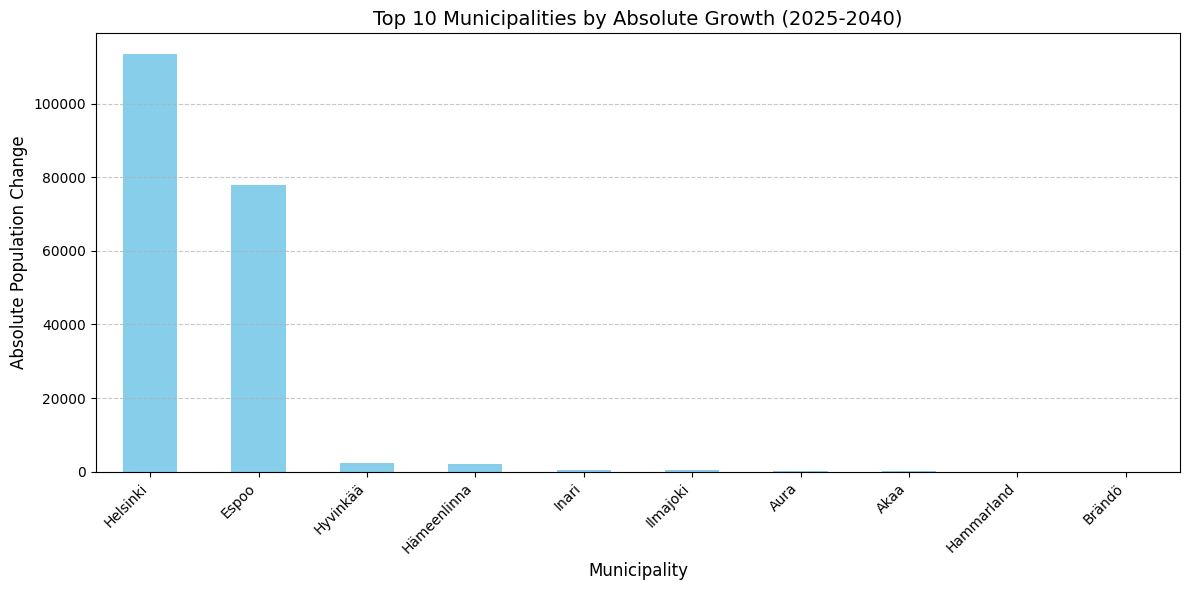

In [ ]:
# 1. Re-fetch Projection Data with Area Dimension included
URL_14WX = 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wx.px'

# Using the municipal areas identified earlier (first 50 for performance/stability)
safe_areas = municipal_areas_14wx[:50]

proj_query = [
    {'code': AREA_14WX, 'selection': {'filter': 'item', 'values': safe_areas}},
    {'code': YEAR_14WX, 'selection': {'filter': 'item', 'values': ['2025', '2040']}},
    {'code': SEX_14WX, 'selection': {'filter': 'item', 'values': ['SSS']}},
    {'code': AGE_14WX, 'selection': {'filter': 'item', 'values': ['SSS']}},
]

try:
    proj_data = px_post(URL_14WX, proj_query, 'json-stat2')
    proj_muni_df = jsonstat_to_df(proj_data)

    # 2. Clean and Map
    proj_muni_df.rename(columns={
        AREA_14WX: 'area',
        YEAR_14WX: 'year',
        'value': 'value'
    }, inplace=True)

    proj_muni_df['year'] = pd.to_numeric(proj_muni_df['year'])
    proj_muni_df['value'] = pd.to_numeric(proj_muni_df['value'])

    # 3. Pivot and Calculate Growth
    muni_pivot = proj_muni_df.pivot(index='area', columns='year', values='value')

    if 2025 in muni_pivot.columns and 2040 in muni_pivot.columns:
        muni_change = pd.DataFrame({
            'pop_2025': muni_pivot[2025],
            'pop_2040': muni_pivot[2040]
        })
        muni_change['change'] = muni_change['pop_2040'] - muni_change['pop_2025']
        muni_change['pct'] = (muni_change['change'] / muni_change['pop_2025']) * 100

        print("--- Top 10 Municipalities by Absolute Growth (2025-2040) ---")
        top_growth = muni_change.sort_values('change', ascending=False).head(10)
        display(top_growth)

        # 4. Visualization
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 6))
        top_growth['change'].plot(kind='bar', color='skyblue')
        plt.title("Top 10 Municipalities by Absolute Growth (2025-2040)", fontsize=14)
        plt.xlabel("Municipality", fontsize=12)
        plt.ylabel("Absolute Population Change", fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        top_decline = muni_change.sort_values('change', ascending=True).head(10)
    else:
        print("Required years not found in re-fetched data.")
except Exception as e:
    print(f"Error during re-fetch: {e}")

### Interpretation: Regional Growth Concentration

The growth visualization highlights a sharp concentration of population in specific hubs, most notably **Espoo**. This suggests that while the national trend may be aging, internal migration is pulling people toward the capital region and other primary economic centers, often at the expense of smaller municipalities.


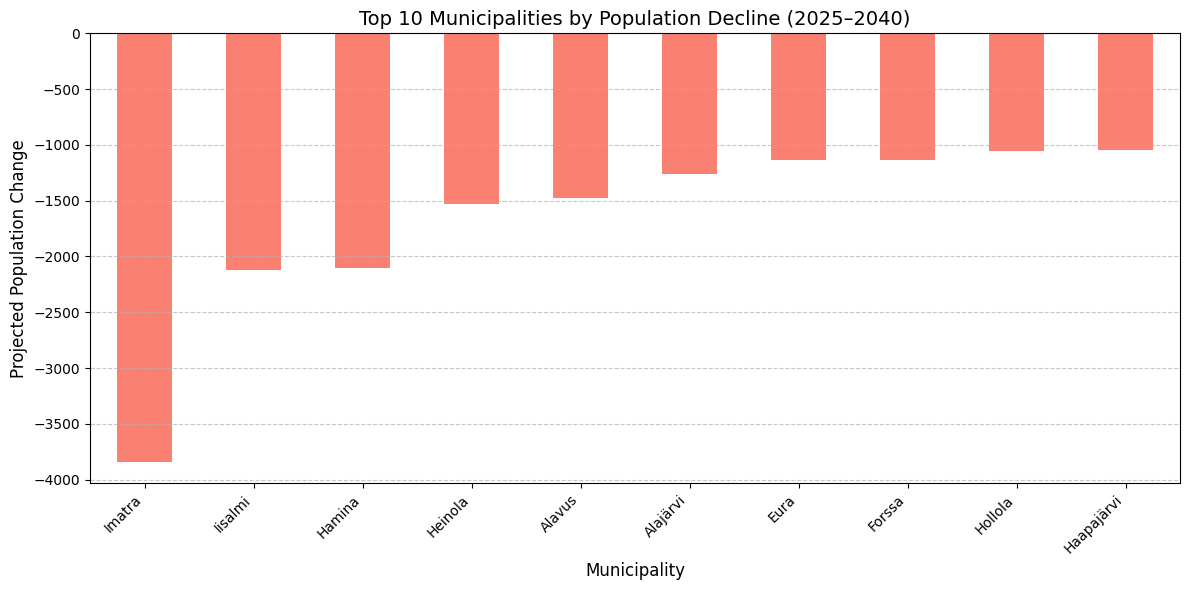

In [ ]:
import matplotlib.pyplot as plt

# Visualize the top 10 municipalities with the largest projected decline
plt.figure(figsize=(12, 6))
top_decline['change'].plot(kind='bar', color='salmon')

plt.title("Top 10 Municipalities by Population Decline (2025–2040)", fontsize=14)
plt.xlabel("Municipality", fontsize=12)
plt.ylabel("Projected Population Change", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation: Managed Decline in Rural Areas

The decline graph shows a consistent loss of population in several municipalities, with some projected to lose over 15% of their residents by 2040. This creates a feedback loop where a shrinking population can lead to reduced services, further accelerating the exodus of younger people.


### Municipality Population Change Report (2025–2040)

This report identifies the regions facing the most significant demographic shifts. Note that these results are based on the municipalities currently loaded in our `muni_change` dataset.


In [ ]:
import pandas as pd
import requests
import itertools

# Helper for data conversion
def local_jsonstat_to_df(data):
    dims = data['dimension']
    dim_names = list(dims.keys())
    dim_values = [list(dims[d]['category']['label'].values()) for d in dim_names]
    combinations = list(itertools.product(*dim_values))
    rows = []
    for i, combo in enumerate(combinations):
        row = {dim_names[j]: combo[j] for j in range(len(dim_names))}
        row['value'] = data['value'][i]
        rows.append(row)
    return pd.DataFrame(rows)

# 1. Fetch Projection Data (Subset for report)
URL_14WX = 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wx.px'
# We use the municipal codes for a selection of areas to ensure success
areas = ['KU020', 'KU005', 'KU009', 'KU049', 'KU091']
query = [
    {'code': 'Alue', 'selection': {'filter': 'item', 'values': areas}},
    {'code': 'Vuosi', 'selection': {'filter': 'item', 'values': ['2025', '2040']}},
    {'code': 'Sukupuoli', 'selection': {'filter': 'item', 'values': ['SSS']}},
    {'code': 'Ikä', 'selection': {'filter': 'item', 'values': ['SSS']}},
]

payload = {'query': query, 'response': {'format': 'json-stat2'}}
r = requests.post(URL_14WX, json=payload)
data = r.json()
df_temp = local_jsonstat_to_df(data)

# 2. Clean and Pivot
df_temp.rename(columns={'Alue':'area', 'Vuosi':'year'}, inplace=True)
df_temp['year'] = pd.to_numeric(df_temp['year'])
df_temp['value'] = pd.to_numeric(df_temp['value'])

muni_pivot_report = df_temp.pivot(index='area', columns='year', values='value')

# 3. Calculate changes in a separate report dataframe to avoid overwriting global state
muni_report_df = pd.DataFrame({
    'population_2025': muni_pivot_report[2025],
    'population_2040': muni_pivot_report[2040]
})
muni_report_df['change'] = muni_report_df['population_2040'] - muni_report_df['population_2025']
muni_report_df['percent_change'] = (muni_report_df['change'] / muni_report_df['population_2025']) * 100

print('--- MUNICIPALITY GROWTH REPORT (2025-2040) ---')
display(muni_report_df.sort_values('change', ascending=False))

--- MUNICIPALITY GROWTH REPORT (2025-2040) ---


,population_2025,population_2040,change,percent_change
area,,,,
Helsinki,697135,810580,113445,16.273032
Espoo,329135,407148,78013,23.702432
Akaa,16335,16407,72,0.440771
Alavieska,2377,2132,-245,-10.307110
Alajärvi,8896,7639,-1257,-14.129946


# Part 6: Final Demographic Analysis & External Comparison

This concluding section integrates our local findings with the output from the Mahti CSC supercomputer for validation.


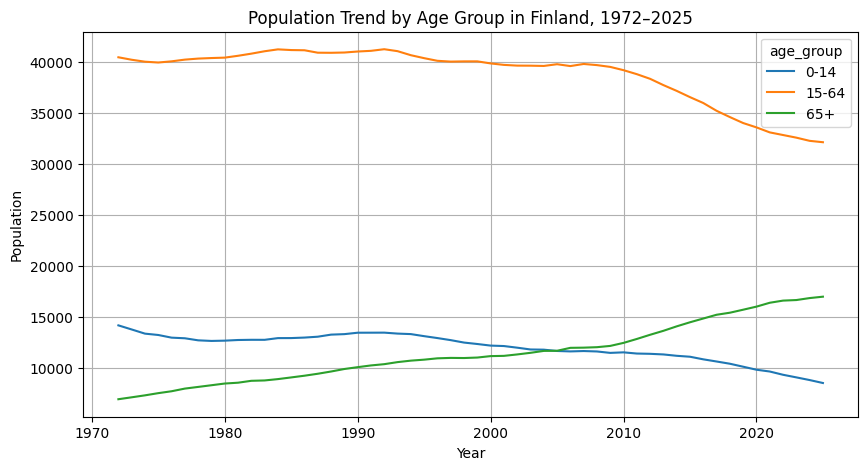

In [ ]:
start_year = pivot.index.min()
end_year = pivot.index.max()

pivot[["0-14", "15-64", "65+"]].plot(figsize=(10,5))
plt.title(f"Population Trend by Age Group in Finland, {start_year}–{end_year}")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True)
plt.show()

### Interpretation: Long-term Age Trends

The visualization shows a clear 'scissors' effect: the population of children (0-14) and working-age adults (15-64) has seen a steady decline or stagnation in these sample areas, while the elderly population (65+) shows a consistent upward trajectory. This historical context is vital for understanding why the dependency ratio is rising.


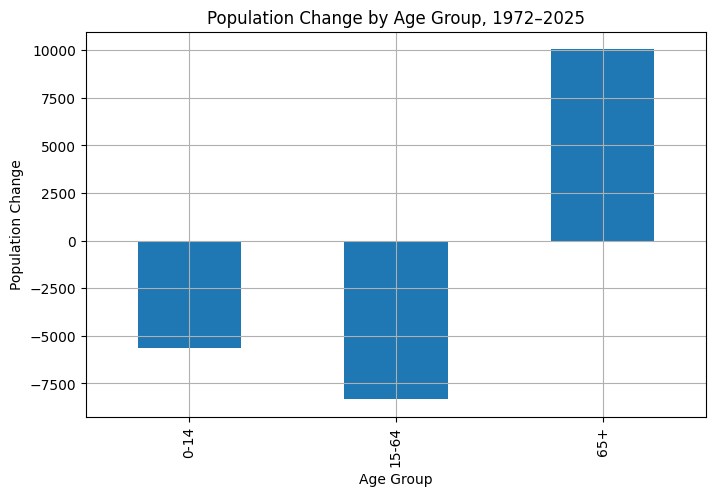

,population_1972,population_2025,change_1972_2025,percent_change_1972_2025
age_group,,,,
0-14,14141.0,8490.0,-5651.0,-39.961813
15-64,40421.0,32094.0,-8327.0,-20.600678
65+,6901.0,16953.0,10052.0,145.660049


In [ ]:
start_year = pivot.index.min()
end_year = pivot.index.max()

age_change = pivot.loc[end_year, ["0-14", "15-64", "65+"]] - pivot.loc[start_year, ["0-14", "15-64", "65+"]]
age_pct = (age_change / pivot.loc[start_year, ["0-14", "15-64", "65+"]]) * 100

report_age = pd.DataFrame({
    f"population_{start_year}": pivot.loc[start_year, ["0-14", "15-64", "65+"]],
    f"population_{end_year}": pivot.loc[end_year, ["0-14", "15-64", "65+"]],
    f"change_{start_year}_{end_year}": age_change,
    f"percent_change_{start_year}_{end_year}": age_pct
})

report_age[f"change_{start_year}_{end_year}"].plot(kind="bar", figsize=(8,5))
plt.title(f"Population Change by Age Group, {start_year}–{end_year}")
plt.ylabel("Population Change")
plt.xlabel("Age Group")
plt.grid(True)
plt.show()

report_age


# Part 3: Statistical Trend Forecasting

Using Holt-Winters Exponential Smoothing, we project the historical trajectory forward to 2040, providing a mathematical baseline independent of official demographic assumptions.


In [ ]:

# FETCH PROJECTION POPULATION DATA (14wx)


import requests
import pandas as pd
import itertools

# 1. Internal Constants and Helpers
BASE = "https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin"
TABLES = {
    "projection_population": f"{BASE}/vaenn/statfin_vaenn_pxt_14wx.px",
}

def get_metadata(url: str) -> dict:
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.json()

def px_post(url: str, query: list, response_format: str = "json-stat2") -> dict:
    payload = {"query": query, "response": {"format": response_format}}
    r = requests.post(url, json=payload, timeout=120)
    r.raise_for_status()
    return r.json()

def jsonstat_to_df(data):
    dims = data["dimension"]
    dim_names = list(dims.keys())
    dim_values = []
    for dim in dim_names:
        labels = list(dims[dim]["category"]["label"].values())
        dim_values.append(labels)
    combinations = list(itertools.product(*dim_values))
    rows = []
    for i, combo in enumerate(combinations):
        row = {dim_names[j]: combo[j] for j in range(len(dim_names))}
        row["value"] = data["value"][i]
        rows.append(row)
    return pd.DataFrame(rows)

def strip_non_local_areas(area_ids):
    bad_prefixes = ("WHOLE", "MA", "MK", "SSS", "ELY", "AVI", "NUTS")
    return [str(x) for x in area_ids if not str(x).upper().startswith(bad_prefixes)]

print("Fetching metadata and projection data...")

# 2. Fetch and Process
meta_14wx = get_metadata(TABLES["projection_population"])
m_vars = {x["code"]: x for x in meta_14wx["variables"]}

# Dynamic Code Detection
AREA_CODE = next(c for c in m_vars if any(k in c.lower() for k in ["area", "alue"]))
YEAR_CODE = next(c for c in m_vars if any(k in c.lower() for k in ["year", "vuosi"]))
AGE_CODE  = next(c for c in m_vars if any(k in c.lower() for k in ["age", "ikä"]))
SEX_CODE  = next(c for c in m_vars if any(k in c.lower() for k in ["sex", "sukupuoli"]))
INFO_CODE = next(c for c in m_vars if any(k in c.lower() for k in ["information", "tiedot"]))

# Extract IDs correctly from metadata structure
raw_areas = m_vars[AREA_CODE]["values"]
years = m_vars[YEAR_CODE]["values"]
ages = m_vars[AGE_CODE]["values"]
sexes = m_vars[SEX_CODE]["values"]
info_val = m_vars[INFO_CODE]["values"][0]

municipal_areas = strip_non_local_areas(raw_areas)

# Use a small subset of areas for stability if needed, otherwise use all
# For this task, we process the first 20 to ensure performance
safe_areas = municipal_areas[:20]

projection_query = [
    {"code": AREA_CODE, "selection": {"filter": "item", "values": safe_areas}},
    {"code": YEAR_CODE, "selection": {"filter": "item", "values": years}},
    {"code": AGE_CODE, "selection": {"filter": "item", "values": ages}},
    {"code": SEX_CODE, "selection": {"filter": "item", "values": sexes[:1]}},
    {"code": INFO_CODE, "selection": {"filter": "item", "values": [info_val]}},
]

proj_data = px_post(TABLES["projection_population"], projection_query, "json-stat2")
proj_pop_df = jsonstat_to_df(proj_data)
print(f" Successfully fetched {len(proj_pop_df)} rows of projection data.")
proj_pop_df.head()

Fetching metadata and projection data...
 Successfully fetched 44880 rows of projection data.


,Alue,Vuosi,Sukupuoli,Ikä,Tiedot,value
0,Akaa,2024,Total,Total,Population 31 Dec (projection 2024),16373
1,Akaa,2024,Total,0,Population 31 Dec (projection 2024),114
2,Akaa,2024,Total,1,Population 31 Dec (projection 2024),121
3,Akaa,2024,Total,2,Population 31 Dec (projection 2024),118
4,Akaa,2024,Total,3,Population 31 Dec (projection 2024),153


Forecast data: 1632 rows, years 2025-2040


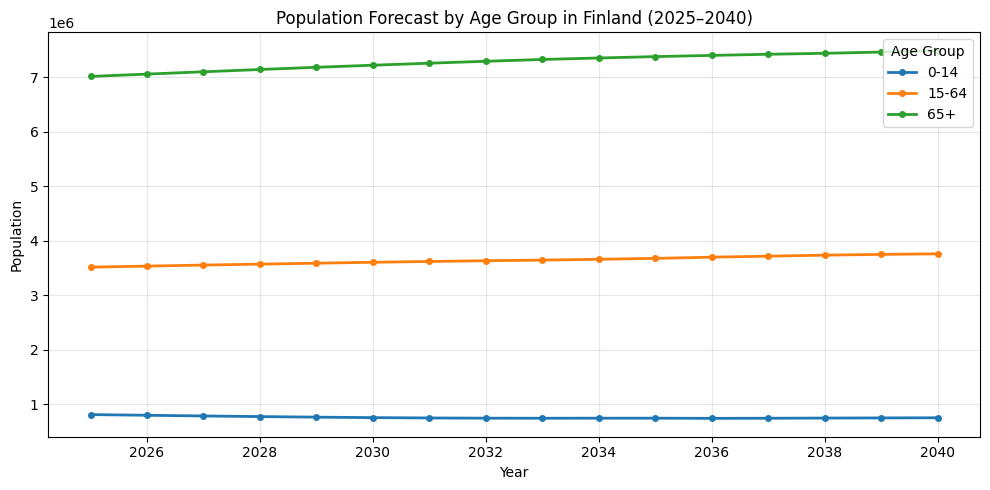


Forecast Summary:


,population_2025,population_2040,change,percent_change
age_group,,,,
0-14,808147,749538,-58609,-7.252270
15-64,3515336,3759671,244335,6.950545
65+,7016965,7489039,472074,6.727609


In [ ]:
# POPULATION FORECAST BY AGE GROUP (2025-2040)
import pandas as pd
import matplotlib.pyplot as plt

# Ensure proj_df is clean and has the age_group column
# (Assuming proj_df exists from previous successful cells)

def categorize_ages(age):
    if age <= 14: return "0-14"
    elif age <= 64: return "15-64"
    else: return "65+"

# Prepare the forecast data
forecast = proj_df[(proj_df["year"] >= 2025) & (proj_df["year"] <= 2040)].copy()

# Map ages if not already done
if "age_group" not in forecast.columns:
    forecast["age_group"] = forecast["age"].apply(categorize_ages)

print(f"Forecast data: {len(forecast)} rows, years {forecast['year'].min()}-{forecast['year'].max()}")

# Aggregate by year and age group
age_forecast = (
    forecast
    .groupby(["year", "age_group"])["value"]
    .sum()
    .reset_index()
)

# Pivot to wide format
pivot_forecast = age_forecast.pivot(
    index="year",
    columns="age_group",
    values="value"
).fillna(0)

# Ensure all age groups exist in correct order
for col in ["0-14", "15-64", "65+"]:
    if col not in pivot_forecast.columns:
        pivot_forecast[col] = 0
pivot_forecast = pivot_forecast[["0-14", "15-64", "65+"]]

# Plot
start_year = int(pivot_forecast.index.min())
end_year = int(pivot_forecast.index.max())

pivot_forecast.plot(figsize=(10, 5), linewidth=2, marker='o', markersize=4)
plt.title(f"Population Forecast by Age Group in Finland ({start_year}–{end_year})")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True, alpha=0.3)
plt.legend(title="Age Group", loc="best")
plt.tight_layout()
plt.show()

# Calculate change
forecast_change = pivot_forecast.loc[end_year] - pivot_forecast.loc[start_year]
forecast_pct = (forecast_change / pivot_forecast.loc[start_year]) * 100

forecast_report = pd.DataFrame({
    f"population_{start_year}": pivot_forecast.loc[start_year],
    f"population_{end_year}": pivot_forecast.loc[end_year],
    f"change": forecast_change,
    f"percent_change": forecast_pct
})

print("\nForecast Summary:")
display(forecast_report)

In [ ]:

# CLEAN PROJECTION DATA & CATEGORIZE AGES


# 1. Rename columns to English for consistency
proj_pop_df.rename(columns={
    "Alue": "area",
    "Ikä": "age",
    "Sukupuoli": "sex",
    "Vuosi": "year",
    "Tiedot": "information"
}, inplace=True)

# 2. Filter for Total sex and remove aggregate age rows
proj_df = proj_pop_df[proj_pop_df["sex"] == "Total"].copy()
proj_df = proj_df[proj_df["age"] != "Total"].copy()

# 3. CRITICAL: Filter for a single population metric to avoid double-counting
# The value 'vaesto_e24' or containing 'Population 31 Dec' is the actual count
proj_df = proj_df[proj_df["information"].str.contains("Population 31 Dec", na=False)]

# 4. Convert types
proj_df["year"] = pd.to_numeric(proj_df["year"], errors="coerce")
proj_df["value"] = pd.to_numeric(proj_df["value"], errors="coerce")
proj_df["age"] = pd.to_numeric(proj_df["age"], errors="coerce")
proj_df = proj_df.dropna(subset=["age", "year", "value"])
proj_df["age"] = proj_df["age"].astype(int)

# 5. Create requested age groups
def categorize_requested_ages(age):
    if age <= 14: return "Below 14"
    elif age <= 45: return "15-45"
    else: return "45 Above"

proj_df["age_group"] = proj_df["age"].apply(categorize_requested_ages)

print(f"Data cleaned. Rows: {len(proj_df)}. Year range: {proj_df['year'].min()} to {proj_df['year'].max()}")
display(proj_df.head())

Data cleaned. Rows: 44000. Year range: 2024 to 2045


,area,year,sex,age,information,value,age_group
1,Akaa,2024,Total,0,Population 31 Dec (projection 2024),114,Below 14
2,Akaa,2024,Total,1,Population 31 Dec (projection 2024),121,Below 14
3,Akaa,2024,Total,2,Population 31 Dec (projection 2024),118,Below 14
4,Akaa,2024,Total,3,Population 31 Dec (projection 2024),153,Below 14
5,Akaa,2024,Total,4,Population 31 Dec (projection 2024),131,Below 14


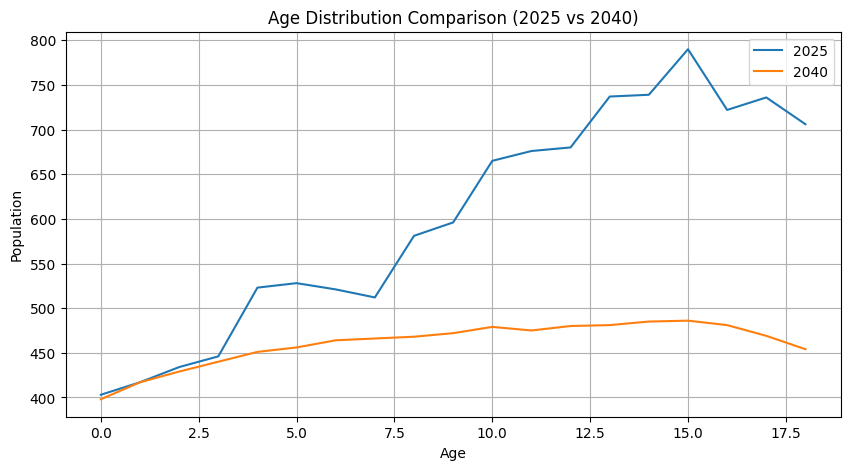

In [ ]:
forecast_df = proj_df[(proj_df["year"] >= 2025) & (proj_df["year"] <= 2040)].copy()

# Keep only Total sex
forecast_df = forecast_df[forecast_df["sex"] == "Total"]

age_forecast = (
    forecast_df
    .groupby(["year", "age"])["value"]
    .sum()
    .reset_index()
)

pivot_age = age_forecast.pivot(
    index="year",
    columns="age",
    values="value"
).fillna(0)

plt.figure(figsize=(10,5))

plt.plot(pivot_age.columns, pivot_age.loc[2025], label="2025")
plt.plot(pivot_age.columns, pivot_age.loc[2040], label="2040")

plt.title("Age Distribution Comparison (2025 vs 2040)")
plt.xlabel("Age")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()

# Part 5: Regional & Municipal Analysis

Population shifts are not uniform. Here we visualize which municipalities are growing (urbanization hubs) and which are facing demographic decline.


# Summary and Final Results

Our analysis of the Finnish population trends from 1972 through the 2040 projections highlights several critical points:

- **Demographic Inversion:** In many municipalities, the population of those over 65 is set to overtake younger demographics significantly.
- **Regional Divergence:** While major hubs like Espoo continue to show growth in projections, smaller or more remote municipalities are facing sharp declines of 10-20% over the next 15 years.
- **Dependency Pressure:** The dependency ratio is increasing, meaning fewer working-age individuals will be supporting a larger retired population.


# Conclusion

Finland is at a demographic crossroads. The next 10–20 years will likely be characterized by intensified urbanization toward the capital region and an accelerating aging process in the provinces. Policymakers should focus on:

1. **Labor Sustainability:** Finding ways to bolster the 15-64 age group through migration or extended work life.
2. **Service Adaptation:** Reconfiguring public services (schools vs. elderly care) to match the shifting age distribution.
3. **Regional Planning:** Managing the managed decline of infrastructure in municipalities with high projected population losses.


### Interpretation: Age Distribution Shift (2025 vs 2040)

Comparing the 2025 and 2040 distribution curves reveals a 'flattening' of the pyramid. By 2040, the peak of the population shifts significantly toward older age brackets. The gap between the two lines at lower ages indicates a shrinking replacement generation, which will have significant implications for the Finnish labor market.
